# ✈️ U.S. Domestic Flight Delay Predictor
**Course:** Machine Learning + Data Analysis & Visualization
**Author:** Bobby Bagley
**Date:** April 2026

---
### 🎯 Objective
Predict whether a U.S. domestic flight will be **delayed ≥ 15 minutes** at departure using only information available before the flight departs.

**Target Variable:** `IS_DELAYED` → binary (1 = delayed ≥ 15 min, 0 = on-time)
**Task Type:** Binary Classification
**Split Strategy:** 70% Train / 15% Validation / 15% Test (stratified)

---
### 📦 Dataset
**Source:** Flight Delay and Cancellation Dataset 2019–2023
**Origin:** U.S. DOT Bureau of Transportation Statistics (BTS) via Kaggle
**Link:** https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023

---
## 0. Environment Setup

In [1]:
# ── Install any missing packages (run once, then comment out) ──────────────
%pip install xgboost lightgbm scikit-learn pandas matplotlib seaborn plotly torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import gc
torch.cuda.empty_cache()    # Clears leftover VRAM  TIM
gc.collect()                # Clears leftover RAM TIM

##  Use Laptop Balance power mode do not use performance to Smooth power delivery and prevents power spikes TIM
'''## Final Run Results

| Model | CPU Time | Wall Time | Status |
|-------|----------|-----------|--------|
| Logistic Regression | 1m 15s | 13m 48s | ✅ Complete |
| Random Forest | 1h 26m 40s | 8m 56s | ✅ Complete |
| XGBoost | 1m 45s | 35m 48s | ✅ Complete |
| **Total** | | **~58 minutes** | ✅ No shutdown |           TIM'''

'## Final Run Results\n\n| Model | CPU Time | Wall Time | Status |\n|-------|----------|-----------|--------|\n| Logistic Regression | 1m 15s | 13m 48s | ✅ Complete |\n| Random Forest | 1h 26m 40s | 8m 56s | ✅ Complete |\n| XGBoost | 1m 45s | 35m 48s | ✅ Complete |\n| **Total** | | **~58 minutes** | ✅ No shutdown |           TIM'

In [3]:
# ── Core ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import kagglehub # This will connect me to the dataset without needing to attach the file
import os
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.model_selection    import train_test_split, RandomizedSearchCV
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import StandardScaler, OneHotEncoder
from sklearn.impute             import SimpleImputer
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_curve,
    confusion_matrix, average_precision_score, log_loss
)
from sklearn.calibration        import CalibrationDisplay

# ── Boosting ───────────────────────────────────────────────────────────────
import xgboost as xgb

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print('All imports successful ✅')

All imports successful ✅


---
## 1. Data Loading & First Look

In [4]:
# Find the dataset
path = kagglehub.dataset_download("patrickzel/flight-delay-and-cancellation-dataset-2019-2023")

# Check inside the folder (if it downloaded correctly)
print(os.listdir(path))

['dictionary.html', 'flights_sample_3m.csv']


In [5]:
# Download the dataset
df_raw = pd.read_csv(path + '/flights_sample_3m.csv')

# Check your work
df_raw.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [6]:
# ── Basic info ─────────────────────────────────────────────────────────────
df_raw.info()
df_raw.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  str    
 1   AIRLINE                  str    
 2   AIRLINE_DOT              str    
 3   AIRLINE_CODE             str    
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   str    
 7   ORIGIN_CITY              str    
 8   DEST                     str    
 9   DEST_CITY                str    
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLATION_CODE  

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3000000,3000000,3000000,3000000,3.000000e+06,3.000000e+06,3000000,3000000,3000000,3000000,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
unique,1704,18,18,18,NaN,NaN,380,373,380,373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2019-07-25,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,NaN,NaN,ATL,"Chicago, IL",ATL,"Chicago, IL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2379,576470,576470,576470,NaN,NaN,153556,157368,153569,158087,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.997629e+04,2.511536e+03,NaN,NaN,NaN,NaN,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,NaN,NaN,NaN,NaN,3.772846e+02,1.747258e+03,NaN,NaN,NaN,NaN,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,NaN,NaN,NaN,NaN,1.939300e+04,1.000000e+00,NaN,NaN,NaN,NaN,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,1.979000e+04,1.051000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,1.993000e+04,2.152000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,2.036800e+04,3.797000e+03,NaN,NaN,NaN,NaN,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000


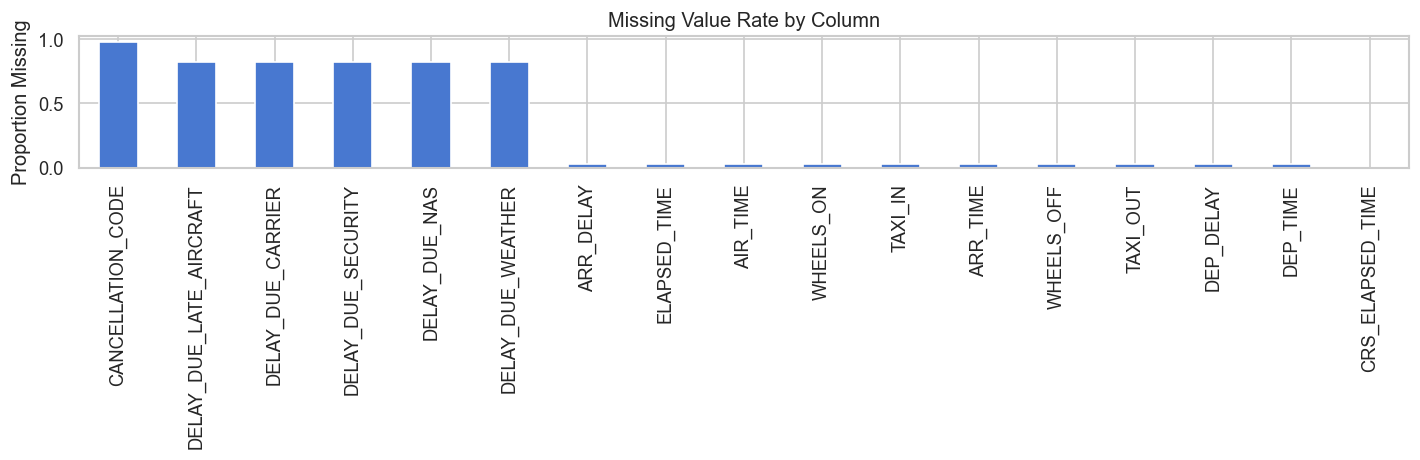

In [7]:
# ── Missing values summary ─────────────────────────────────────────────────
missing = df_raw.isnull().mean().sort_values(ascending=False)
missing[missing > 0].plot(kind='bar', figsize=(12, 4), title='Missing Value Rate by Column')
plt.ylabel('Proportion Missing')
plt.tight_layout()
plt.show()

---
## 2. Data Readiness & Sampling
> ⚠️ **Leakage Warning:** Columns like `ARR_DELAY`, `CARRIER_DELAY`, `WEATHER_DELAY`, etc. contain information that is only known *after* the flight lands. These must be dropped before modeling.

In [8]:
df_raw.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='str')

In [9]:
# ── Drop post-flight leakage columns ───────────────────────────────────────
LEAKAGE_COLS = [
    # Post-flight operational data
    'DEP_TIME', 'TAXI_OUT', 'WHEELS_OFF',
    'WHEELS_ON', 'TAXI_IN', 'ARR_TIME', 'ARR_DELAY',
    'ELAPSED_TIME', 'AIR_TIME',
    # Post-flight delay causes
    'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
    # Redundant / ID columns
    'AIRLINE_DOT', 'DOT_CODE', 'FL_NUMBER',
    'ORIGIN_CITY', 'DEST_CITY',
    # Filtered-out flags (all NaN after dropna)
    'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED',
]

cols_to_drop = [c for c in LEAKAGE_COLS if c in df_raw.columns]
df = df_raw.drop(columns=cols_to_drop).copy()
print(f'Dropped {len(cols_to_drop)} columns. Remaining: {df.shape[1]}')
print(df.columns.tolist())

Dropped 22 columns. Remaining: 10
['FL_DATE', 'AIRLINE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE']


In [10]:
# ── Construct binary target from DEP_DELAY ─────────────────────────────────
# FAA/DOT standard: delayed = departure delay >= 15 minutes
df = df.dropna(subset=['DEP_DELAY']).copy()   # need a valid delay value
df['IS_DELAYED'] = (df['DEP_DELAY'] >= 15).astype(int)
df = df.drop(columns=['DEP_DELAY'])           # drop raw delay — it's the source of the target!

print('Target distribution:')
print(df['IS_DELAYED'].value_counts(normalize=True).rename({0: 'On-Time', 1: 'Delayed'}))
print(df.columns)

Target distribution:
IS_DELAYED
On-Time    0.818007
Delayed    0.181993
Name: proportion, dtype: float64
Index(['FL_DATE', 'AIRLINE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME',
       'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'IS_DELAYED'],
      dtype='str')


**Big note here**: We're going to take a sample of the data: 500K rows.

3M with **Logistic Regression** would be very slow.

In [11]:
print(df.shape)
print(df.dtypes)
print('IS_DELAYED' in df.columns)
print(df['IS_DELAYED'].value_counts())

(2922356, 10)
FL_DATE                 str
AIRLINE                 str
AIRLINE_CODE            str
ORIGIN                  str
DEST                    str
CRS_DEP_TIME          int64
CRS_ARR_TIME          int64
CRS_ELAPSED_TIME    float64
DISTANCE            float64
IS_DELAYED            int64
dtype: object
True
IS_DELAYED
0    2390508
1     531848
Name: count, dtype: int64


In [12]:
# ── Stratified sample for manageable runtime ───────────────────────────────
# Stratify=IS_DELAYED preserves the imbalance ratio in the sample.
# Had to use train_test_split trick bc pandas was acting weird with my other code
SAMPLE_SIZE = 500_000

if len(df) > SAMPLE_SIZE:
    _, df = train_test_split(
        df,
        test_size=SAMPLE_SIZE,
        stratify=df['IS_DELAYED'],
        random_state=SEED
    )
    df = df.reset_index(drop=True)

print(f'Working dataset shape: {df.shape}')
print(df['IS_DELAYED'].value_counts())
print(df.columns.tolist())  # confirm IS_DELAYED is still there

Working dataset shape: (500000, 10)
IS_DELAYED
0    409004
1     90996
Name: count, dtype: int64
['FL_DATE', 'AIRLINE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'IS_DELAYED']


---
## 3. Feature Engineering
> Take time features and break them into *hour*, *day of week*, *month*, and *season* to give the model much more to work with.

In [13]:
# ── Section 3: Feature Engineering ────────────────────────────────────────

# ── Parse date features from FL_DATE ──────────────────────────────────────
df['FL_DATE']     = pd.to_datetime(df['FL_DATE'])
df['MONTH']       = df['FL_DATE'].dt.month
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek + 1  # Monday=1, Sunday=7
df['YEAR']        = df['FL_DATE'].dt.year

# ── Departure time features ────────────────────────────────────────────────
df['HOUR_OF_DAY'] = (df['CRS_DEP_TIME'] // 100).clip(0, 23)
df['IS_WEEKEND']  = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── Season (categorical) ───────────────────────────────────────────────────
def get_season(m):
    return {12:'Winter', 1:'Winter',  2:'Winter',
             3:'Spring',  4:'Spring',  5:'Spring',
             6:'Summer',  7:'Summer',  8:'Summer',
             9:'Fall',   10:'Fall',   11:'Fall'}.get(m, 'Unknown')

df['SEASON'] = df['MONTH'].map(get_season)

# ── Time of day bucket (categorical) ──────────────────────────────────────
def time_bucket(hour):
    if hour < 6:   return 'Red-Eye'
    if hour < 12:  return 'Morning'
    if hour < 17:  return 'Afternoon'
    if hour < 21:  return 'Evening'
    return 'Night'

df['TIME_BUCKET'] = df['HOUR_OF_DAY'].apply(time_bucket)

print('Feature engineering complete ✅')
print(f'Dataset shape: {df.shape}')
df[['HOUR_OF_DAY', 'IS_WEEKEND', 'SEASON', 'TIME_BUCKET']].head()

Feature engineering complete ✅
Dataset shape: (500000, 17)


,HOUR_OF_DAY,IS_WEEKEND,SEASON,TIME_BUCKET
0,18,1,Fall,Evening
1,14,0,Spring,Afternoon
2,9,1,Summer,Morning
3,22,0,Summer,Night
4,10,0,Spring,Morning


In [14]:
df.columns.tolist()

['FL_DATE',
 'AIRLINE',
 'AIRLINE_CODE',
 'ORIGIN',
 'DEST',
 'CRS_DEP_TIME',
 'CRS_ARR_TIME',
 'CRS_ELAPSED_TIME',
 'DISTANCE',
 'IS_DELAYED',
 'MONTH',
 'DAY_OF_WEEK',
 'YEAR',
 'HOUR_OF_DAY',
 'IS_WEEKEND',
 'SEASON',
 'TIME_BUCKET']

In [15]:
# Check my work
df.head()

,FL_DATE,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,IS_DELAYED,MONTH,DAY_OF_WEEK,YEAR,HOUR_OF_DAY,IS_WEEKEND,SEASON,TIME_BUCKET
0,2020-10-03,PSA Airlines Inc.,OH,CLT,SBN,1805,1950,105.0,534.0,0,10,6,2020,18,1,Fall,Evening
1,2023-04-13,American Airlines Inc.,AA,DCA,ORD,1454,1605,131.0,612.0,0,4,4,2023,14,0,Spring,Afternoon
2,2023-08-26,United Air Lines Inc.,UA,DEN,LGA,944,1533,229.0,1620.0,0,8,6,2023,9,1,Summer,Morning
3,2023-07-12,Alaska Airlines Inc.,AS,SEA,DTW,2230,544,254.0,1927.0,0,7,3,2023,22,0,Summer,Night
4,2023-03-09,Spirit Air Lines,NK,ACY,FLL,1017,1304,167.0,977.0,0,3,4,2023,10,0,Spring,Morning


---
## 4. Exploratory Data Analysis (EDA)
> Brief — the emphasis of this project is on modeling. EDA is here to inform feature selection and tell the story in presentation.

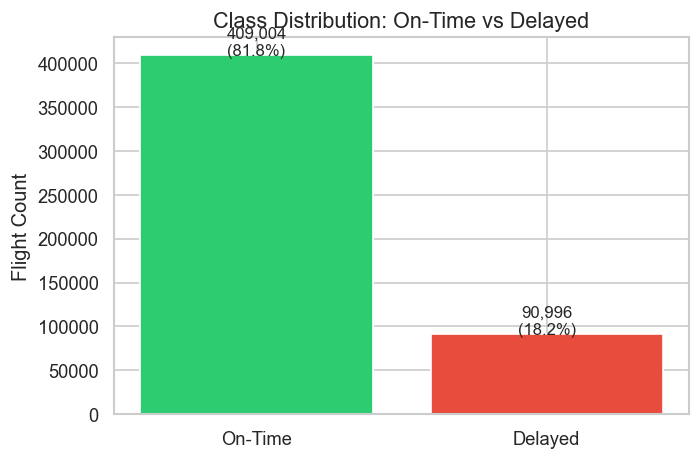

In [16]:
# ── 4.1 Target class balance ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['IS_DELAYED'].value_counts()
ax.bar(['On-Time', 'Delayed'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('Class Distribution: On-Time vs Delayed', fontsize=13)
ax.set_ylabel('Flight Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

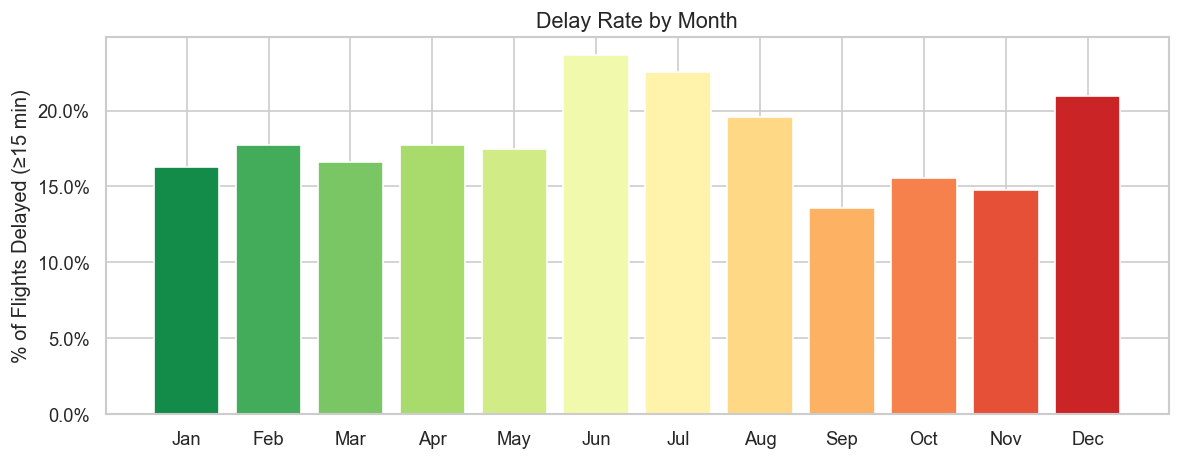

In [17]:
# ── 4.2 Delay rate by Month ────────────────────────────────────────────────
month_delay = df.groupby('MONTH')['IS_DELAYED'].mean().reset_index()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_delay['MONTH_NAME'] = month_delay['MONTH'].map(month_names)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(month_delay['MONTH_NAME'], month_delay['IS_DELAYED'],
       color=sns.color_palette('RdYlGn_r', 12))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Delay Rate by Month', fontsize=13)
ax.set_ylabel('% of Flights Delayed (≥15 min)')
plt.tight_layout()
plt.show()

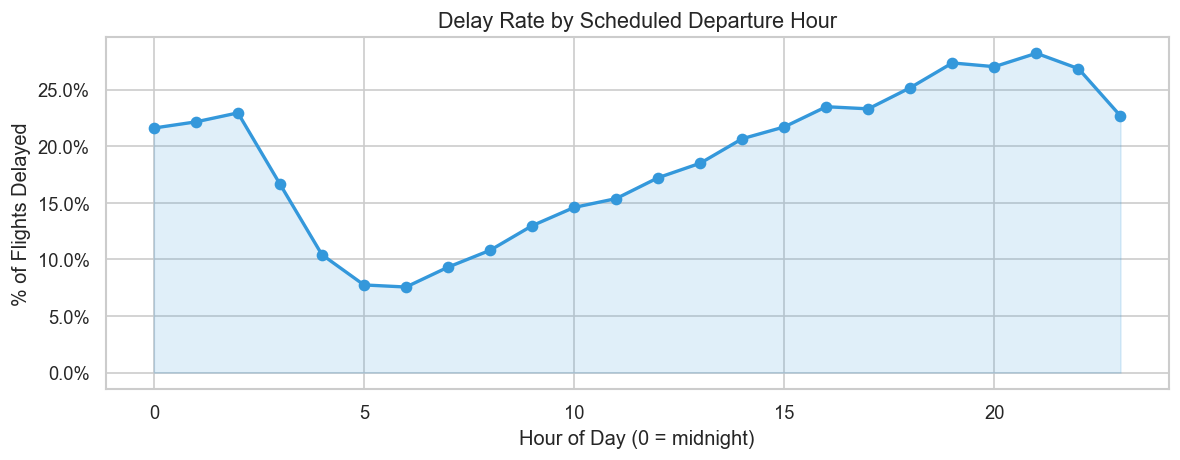

In [18]:
# ── 4.3 Delay rate by Hour of Day ─────────────────────────────────────────
hour_delay = df.groupby('HOUR_OF_DAY')['IS_DELAYED'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hour_delay.index, hour_delay.values, marker='o', color='#3498db', linewidth=2)
ax.fill_between(hour_delay.index, hour_delay.values, alpha=0.15, color='#3498db')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Delay Rate by Scheduled Departure Hour', fontsize=13)
ax.set_xlabel('Hour of Day (0 = midnight)')
ax.set_ylabel('% of Flights Delayed')
plt.tight_layout()
plt.show()

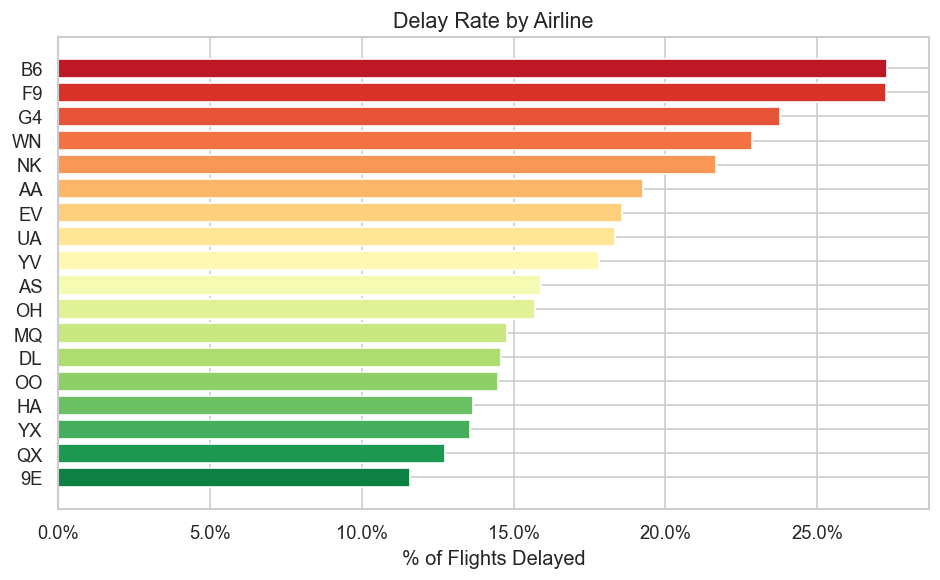

In [19]:
# ── 4.4 Delay rate by Airline ─────────────────────────────────────────────
carrier_col = 'AIRLINE_CODE'

if carrier_col in df.columns:
    carrier_delay = (df.groupby(carrier_col)['IS_DELAYED']
                     .agg(['mean', 'count'])
                     .query('count > 1000')
                     .sort_values('mean', ascending=True))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(carrier_delay.index, carrier_delay['mean'],
            color=sns.color_palette('RdYlGn_r', len(carrier_delay)))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title('Delay Rate by Airline', fontsize=13)
    ax.set_xlabel('% of Flights Delayed')
    plt.tight_layout()
    plt.show()

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   FL_DATE           500000 non-null  datetime64[us]
 1   AIRLINE           500000 non-null  str           
 2   AIRLINE_CODE      500000 non-null  str           
 3   ORIGIN            500000 non-null  str           
 4   DEST              500000 non-null  str           
 5   CRS_DEP_TIME      500000 non-null  int64         
 6   CRS_ARR_TIME      500000 non-null  int64         
 7   CRS_ELAPSED_TIME  500000 non-null  float64       
 8   DISTANCE          500000 non-null  float64       
 9   IS_DELAYED        500000 non-null  int64         
 10  MONTH             500000 non-null  int32         
 11  DAY_OF_WEEK       500000 non-null  int32         
 12  YEAR              500000 non-null  int32         
 13  HOUR_OF_DAY       500000 non-null  int64         
 14  IS_WEEKEND     

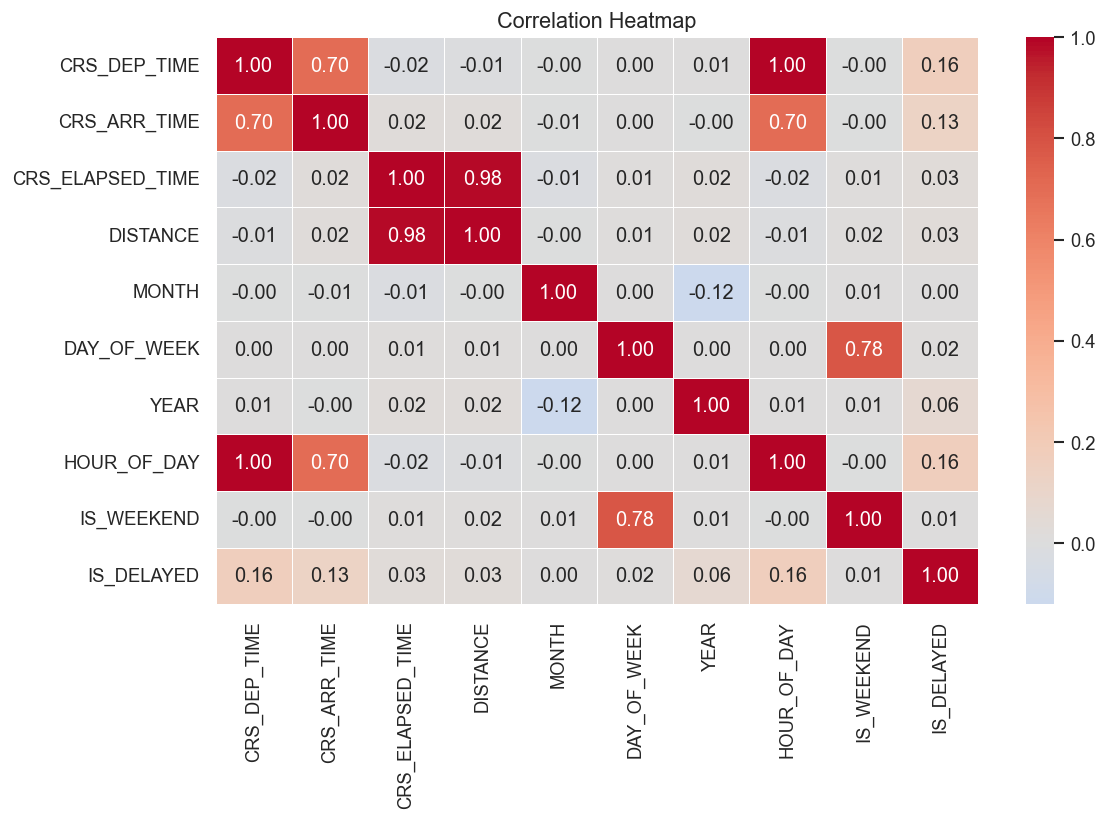

In [21]:
# ── 4.5 Correlation heatmap (numeric features only) ────────────────────────
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['IS_DELAYED']).columns.tolist()
corr = df[numeric_cols + ['IS_DELAYED']].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

### Correlation with `IS_DELAYED`

| Feature | Correlation | Interpretation |
|---|---|---|
| `CRS_DEP_TIME` / `HOUR_OF_DAY` | 0.16 | Strongest signal — confirms the domino effect finding from the viz project |
| `CRS_ARR_TIME` | 0.13 | Mostly redundant with DEP_TIME as expected |
| `YEAR` | 0.06 | Slight upward trend in delays post-COVID recovery |
| `DAY_OF_WEEK` | 0.02 | Confirms what Chapter 1 showed — day of week is a weak predictor |
| `CRS_ELAPSED_TIME` / `DISTANCE` | 0.03 | Distance barely matters — matches the scatter plot finding from Chapter 4 |
| `MONTH` | 0.00 | Surprising at face value — linear correlation misses the non-linear seasonal peaks |
| `IS_WEEKEND` | 0.01 | Essentially zero linear relationship with delays |

> **Note:** All correlations with the target are low. The hope is that our chosen tree-based models (Random Forest, XGBoost) will capture non-linear relationships that correlation misses.

### Multicollinearity Concerns

| Pair | Correlation | Action |
|---|---|---|
| `CRS_DEP_TIME` ↔ `HOUR_OF_DAY` | 1.00 | 🚨 Perfect collinearity — `HOUR_OF_DAY` is derived directly from `CRS_DEP_TIME`. Drop `CRS_DEP_TIME`. |
| `CRS_ELAPSED_TIME` ↔ `DISTANCE` | 0.98 | 🚨 Near-perfect — longer routes take longer to fly. Drop `DISTANCE`. |
| `DAY_OF_WEEK` ↔ `IS_WEEKEND` | 0.78 | ⚠️ High — `IS_WEEKEND` is derived from `DAY_OF_WEEK`. Drop `IS_WEEKEND`. |
| `CRS_DEP_TIME` ↔ `CRS_ARR_TIME` | 0.70 | ⚠️ High — `CRS_ARR_TIME` adds little beyond what `CRS_DEP_TIME` already captures. Drop `CRS_ARR_TIME`. |

Even though I made `IS_WEEKEND` just a few blocks ago, we should drop it since it's super weak correlation with `IS_DELAYED`. Plus, whatever I lose by dropping `IS_WEEKEND`, I get back by keeping `DAY_OF_WEEK`, hopefully.

In [22]:
# Remove perfectly/near-perfectly collinear features

COLLINEAR_DROPS = [
    'CRS_DEP_TIME',    # keep HOUR_OF_DAY — eaiser to understand
    'DISTANCE',        # keep CRS_ELAPSED_TIME — slightly more predictive maybe
    'IS_WEEKEND',      # keep DAY_OF_WEEK — more granular
    'CRS_ARR_TIME',    # redundant with CRS_DEP_TIME + CRS_ELAPSED_TIME
    'FL_DATE'          # Not a collinear drop, but need to drop before i run through modeling bc scalers
]

cols_to_drop = [c for c in COLLINEAR_DROPS if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Remaining features: {df.columns.tolist()}')
df.info()

Remaining features: ['AIRLINE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_ELAPSED_TIME', 'IS_DELAYED', 'MONTH', 'DAY_OF_WEEK', 'YEAR', 'HOUR_OF_DAY', 'SEASON', 'TIME_BUCKET']
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   AIRLINE           500000 non-null  str    
 1   AIRLINE_CODE      500000 non-null  str    
 2   ORIGIN            500000 non-null  str    
 3   DEST              500000 non-null  str    
 4   CRS_ELAPSED_TIME  500000 non-null  float64
 5   IS_DELAYED        500000 non-null  int64  
 6   MONTH             500000 non-null  int32  
 7   DAY_OF_WEEK       500000 non-null  int32  
 8   YEAR              500000 non-null  int32  
 9   HOUR_OF_DAY       500000 non-null  int64  
 10  SEASON            500000 non-null  str    
 11  TIME_BUCKET       500000 non-null  str    
dtypes: float64(1), int32(3), int64(2), str(6)
memory us

---
## 5. Train / Validation / Test Split
> **Split rationale:** 70/15/15 stratified on `IS_DELAYED`. We use the validation set to compare models and pick the winner — the test set is touched exactly once, at the very end.

In [23]:
# ── Define features ────────────────────────────────────────────────────────
# ✏️ Customize this list based on what columns exist in your dataset
NUMERIC_FEATURES = [
    'CRS_ELAPSED_TIME', 
    'MONTH', 
    'DAY_OF_WEEK',
    'YEAR', 
    'HOUR_OF_DAY'
]

CATEGORICAL_FEATURES = [
    'AIRLINE', 
    'ORIGIN',
    'DEST', 
    'SEASON', 
    'TIME_BUCKET'
]

# Keep only columns that exist in the dataframe
NUMERIC_FEATURES    = [c for c in NUMERIC_FEATURES    if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET   = 'IS_DELAYED'

X = df[FEATURES]
y = df[TARGET]

print(f'Feature count: {len(FEATURES)}')
print(f'  Numeric:     {NUMERIC_FEATURES}')
print(f'  Categorical: {CATEGORICAL_FEATURES}')

Feature count: 10
  Numeric:     ['CRS_ELAPSED_TIME', 'MONTH', 'DAY_OF_WEEK', 'YEAR', 'HOUR_OF_DAY']
  Categorical: ['AIRLINE', 'ORIGIN', 'DEST', 'SEASON', 'TIME_BUCKET']


In [24]:
# ── 70 / 15 / 15 stratified split ─────────────────────────────────────────
X_temp, X_test,  y_temp, y_test  = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val   = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=SEED
)

print(f'Train size:      {len(X_train):,} ({len(X_train)/len(X):.1%})')
print(f'Validation size: {len(X_val):,}   ({len(X_val)/len(X):.1%})')
print(f'Test size:       {len(X_test):,}   ({len(X_test)/len(X):.1%})')

# Confirm stratification held
print('\nDelay rate in each split:')
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {name}: {y_split.mean():.3f}')

Train size:      350,000 (70.0%)
Validation size: 75,000   (15.0%)
Test size:       75,000   (15.0%)

Delay rate in each split:
  Train: 0.182
  Val: 0.182
  Test: 0.182


---
## 6. Preprocessing Pipeline
> **Key rule:** All transformers (scaler, encoder, imputer) are `.fit()` on training data ONLY, then `.transform()` on val/test. Fitting on val or test would be committing the sin of data leakage 🤕.

In [25]:
# ── Build preprocessing pipeline ───────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

print('Preprocessor built ✅')

Preprocessor built ✅


---
## 7. Model Development & Tuning

We train **3 distinct models** — think of them as three different problem-solving strategies:
- 🟦 **Logistic Regression** → the "straight line" approach; fast, interpretable baseline
- 🌲 **Random Forest** → a crowd of decision trees voting together
- ⚡ **XGBoost** → trees that learn from each other's mistakes, iteratively

**Workflow**
1. Define pipelines
2. Tune each model with `RandomizedSearchCV` (TRAINING DATA ONLY)
3. Evaluate the BEST VERSION of each on the validation set
4. Compare tuned models and choose winner

**Note**:
* Make sure I'm using a GPU for XGBoost.
* **CANCELLED** RandomForest might take a while since it can't use a GPU. try tuning with only a subset of data.
* buckle up buddy...

In [26]:
# Cancel this subsetting. We will use the full training set for all models, but I wanted to keep this code here in case I needed to do it again for testing or something.
'''
X_train_sub = X_train.sample(n=200_000, random_state=SEED)
y_train_sub = y_train.loc[X_train_sub.index]
print(f'RF subsample size: {X_train_sub.shape[0]:,}')
'''

"\nX_train_sub = X_train.sample(n=200_000, random_state=SEED)\ny_train_sub = y_train.loc[X_train_sub.index]\nprint(f'RF subsample size: {X_train_sub.shape[0]:,}')\n"

### Helper
Pipeline helper to tune and eval on validation set

In [27]:
# NEW HELPER: tune + evaluate on validation set
def tune_and_evaluate(name, pipeline, param_dist, X_tr, y_tr, X_v, y_v,
                      n_iter=5, cv=3):
    print(f'\n── Tuning {name} ──')
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        n_jobs=-1,
        random_state=SEED,
        error_score=0
    )
    search.fit(X_tr, y_tr)

    best = search.best_estimator_
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV AUC: {search.best_score_:.4f}')

    # ── Predictions ────────────────────────────────────────────────────────
    y_pred  = best.predict(X_v)
    y_proba = best.predict_proba(X_v)[:, 1]

    # ── Three metrics ──────────────────────────────────────────────────────
    roc_auc  = roc_auc_score(y_v, y_proba)
    pr_auc   = average_precision_score(y_v, y_proba)   # PR-AUC
    logloss  = log_loss(y_v, y_proba)                  # Log Loss

    print(f'\n{"─"*40}')
    print(f'  {"Metric":<20} {"Score":>10}')
    print(f'{"─"*40}')
    print(f'  {"ROC-AUC":<20} {roc_auc:>10.4f}   ↑ higher is better')
    print(f'  {"PR-AUC":<20} {pr_auc:>10.4f}   ↑ higher is better')
    print(f'  {"Log Loss":<20} {logloss:>10.4f}   ↓ lower is better')
    print(f'{"─"*40}')
    print(classification_report(y_v, y_pred, target_names=['On-Time', 'Delayed']))

    return {
        'name':     name,
        'pipeline': best,
        'auc':      roc_auc,
        'pr_auc':   pr_auc,
        'logloss':  logloss,
        'params':   search.best_params_
    }

In [28]:
# ── OLD HELPER: tune + evaluate on validation set ──────────────────────────────
# Due to computational constraints of running three models on a large dataset, cv=3 was used to prevent system instability. Validation set results are consistent with cross validation scores, suggesting the lower fold count did not significantly impact model reliability.  TIM
'''
def tune_and_evaluate(name, pipeline, param_dist, X_tr, y_tr, X_v, y_v,
                      n_iter=5, cv=3):
    print(f'\n── Tuning {name} ──')
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        n_jobs=-1,                      ## possible change from -1 (unlimited) to 20 (limits CPU utilization). Works currently!
        random_state=SEED
    )
    search.fit(X_tr, y_tr)

    best = search.best_estimator_
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV AUC: {search.best_score_:.4f}')

    # Evaluate best version on validation set
    y_pred  = best.predict(X_v)
    y_proba = best.predict_proba(X_v)[:, 1]

    auc = roc_auc_score(y_v, y_proba)
    f1  = f1_score(y_v, y_pred, average='weighted')

    print(f'\n  Validation ROC-AUC: {auc:.4f}')
    print(f'  Validation F1:      {f1:.4f}')
    print(classification_report(y_v, y_pred, target_names=['On-Time', 'Delayed']))

    return {
        'name':     name,
        'pipeline': best,       # store the BEST estimator, not the search object
        'auc':      auc,
        'f1':       f1,
        'params':   search.best_params_
    }
    '''

"\ndef tune_and_evaluate(name, pipeline, param_dist, X_tr, y_tr, X_v, y_v,\n                      n_iter=5, cv=3):\n    print(f'\n── Tuning {name} ──')\n    search = RandomizedSearchCV(\n        pipeline,\n        param_distributions=param_dist,\n        n_iter=n_iter,\n        scoring='roc_auc',\n        cv=cv,\n        verbose=1,\n        n_jobs=-1,                      ## possible change from -1 (unlimited) to 20 (limits CPU utilization). Works currently!\n        random_state=SEED\n    )\n    search.fit(X_tr, y_tr)\n\n    best = search.best_estimator_\n    print(f'  Best params: {search.best_params_}')\n    print(f'  Best CV AUC: {search.best_score_:.4f}')\n\n    # Evaluate best version on validation set\n    y_pred  = best.predict(X_v)\n    y_proba = best.predict_proba(X_v)[:, 1]\n\n    auc = roc_auc_score(y_v, y_proba)\n    f1  = f1_score(y_v, y_pred, average='weighted')\n\n    print(f'\n  Validation ROC-AUC: {auc:.4f}')\n    print(f'  Validation F1:      {f1:.4f}')\n    print(cl

### Model 1: Logistic Regression

We are going to tune these 3 hyperparameters:
* `C` -  Regularization strength
This controls how much the model is penalized for having large coefficients. Think of it like a leash on the model's complexity. A small `C` (like 0.01) puts a tight leash — the model is heavily penalized and stays simple. A large `C` (like 10) loosens the leash — the model can fit more aggressively to the training data. We're searching $[0.01, 0.1, 1, 10]$.
* `solver` - Optimization algorithm
This is the mathematical method used to find the best coefficients. Think of it as two different routes to the same destination:

  * `lbfgs` — efficient and reliable for most cases, good default
  * `saga` — better for large datasets, supports more penalty types
* `penalty` - Type of regularization
Controls the shape of the leash. We're only searching `l2` here, which is the standard squared penalty. We're not including `l1` because `lbfgs` doesn't support it — mixing `l1` with `lbfgs` would cause errors.

This took 21min.

In [29]:
%%time
# ── Model 1: Logistic Regression ───────────────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        class_weight='balanced',
        max_iter=200,       # reduced from 500 TIM
        random_state=SEED
    ))
])

param_dist_lr = {
    'classifier__C':       [0.01, 0.1, 1, 10],
    'classifier__solver':  ['lbfgs', 'saga'],
    'classifier__penalty': ['l2'],
}

results_lr = tune_and_evaluate(
    'Logistic Regression',
    lr_pipeline, param_dist_lr,
    X_train, y_train,       # full training set — LR handles it fine
    X_val,   y_val,
    n_iter=5, cv=3                # only test 5 combinations
)


── Tuning Logistic Regression ──
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best params: {'classifier__solver': 'saga', 'classifier__penalty': 'l2', 'classifier__C': 0.01}
  Best CV AUC: 0.6639

────────────────────────────────────────
  Metric                    Score
────────────────────────────────────────
  ROC-AUC                  0.6725   ↑ higher is better
  PR-AUC                   0.3182   ↑ higher is better
  Log Loss                 0.6473   ↓ lower is better
────────────────────────────────────────
              precision    recall  f1-score   support

     On-Time       0.88      0.61      0.72     61351
     Delayed       0.27      0.64      0.38     13649

    accuracy                           0.62     75000
   macro avg       0.58      0.63      0.55     75000
weighted avg       0.77      0.62      0.66     75000

CPU times: total: 49.2 s
Wall time: 7min 5s


### Model 2: Random Forest
RF was supposed to be the slowest. It was not — using the subsample, `cv=2` means 2 fits per combination x 5 combinations = 10 total fits. This took 6:24.

In [30]:
%%time
# ── Model 2: Random Forest ─────────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        class_weight='balanced',
        n_jobs=-1,           # -1 (unlimited) change 20 to limit cpu  TIM
        random_state=SEED
    ))
])

param_dist_rf = {
    'classifier__n_estimators':     [100, 200, 300],
    'classifier__max_depth':        [None, 10, 20],
    'classifier__min_samples_split':[5, 5, 25],
}

results_rf = tune_and_evaluate(
    'Random Forest',
    rf_pipeline, param_dist_rf,
    # X_train_sub, y_train_sub,   # ← subsample for RF only
    X_train, y_train,   # changed to Full training set TIM
    X_val,       y_val,
    n_iter=5, cv=3                # Add line TIM
)


── Tuning Random Forest ──
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 25, 'classifier__max_depth': None}
  Best CV AUC: 0.6915

────────────────────────────────────────
  Metric                    Score
────────────────────────────────────────
  ROC-AUC                  0.6956   ↑ higher is better
  PR-AUC                   0.3530   ↑ higher is better
  Log Loss                 0.5165   ↓ lower is better
────────────────────────────────────────
              precision    recall  f1-score   support

     On-Time       0.86      0.86      0.86     61351
     Delayed       0.37      0.37      0.37     13649

    accuracy                           0.77     75000
   macro avg       0.62      0.62      0.62     75000
weighted avg       0.77      0.77      0.77     75000

CPU times: total: 56min 43s
Wall time: 22min 43s


### Model 3: XGBoost

In [31]:
%%time
# ── Model 3: XGBoost ───────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos
print(f'Class imbalance ratio (scale_pos_weight): {scale_weight:.2f}')

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   xgb.XGBClassifier(
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        device='cuda',          # RTX 3060 from my laptop  [I ran a RTX 4060 FYI  Tim]
        tree_method='hist',     # required for GPU
        random_state=SEED,
        nthread=20,             # prevent cpu & gpu from competing  TIM
        max_bin=128,            # keep VRAM from maxing out TIM
    ))
])

param_dist_xgb = {
    'classifier__n_estimators':       [200, 300, 400],
    'classifier__learning_rate':      [0.01, 0.05, 0.1],
    'classifier__max_depth':          [4, 6, 8],
    'classifier__subsample':          [0.7, 0.8, 1.0],
    'classifier__colsample_bytree':   [0.7, 0.8, 1.0],
}
'''possible changes for better proformance
Item                Before                  Suggestion
n_estimators        [200, 300, 400]         [200, 300]
learning_rate       [0.01, 0.05, 0.1]       [0.01, 0.05]
max_depth           [4, 6, 8]               [4, 6]
subsample           [0.7, 0.8, 1.0]         [0.7, 0.8]
colsample_bytree    [0.7, 0.8, 1.0]         [0.7, 0.8]

Suggestion only - Currently Works   TIM'''

results_xgb = tune_and_evaluate(
    'XGBoost',
    xgb_pipeline, param_dist_xgb,
    X_train, y_train,       # full training set — GPU handles it
    X_val,   y_val,
    n_iter=5, cv=3               
)

Class imbalance ratio (scale_pos_weight): 4.49

── Tuning XGBoost ──
Fitting 3 folds for each of 5 candidates, totalling 15 fits
  Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 400, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.7}
  Best CV AUC: 0.7037

────────────────────────────────────────
  Metric                    Score
────────────────────────────────────────
  ROC-AUC                  0.7073   ↑ higher is better
  PR-AUC                   0.3631   ↑ higher is better
  Log Loss                 0.6211   ↓ lower is better
────────────────────────────────────────
              precision    recall  f1-score   support

     On-Time       0.89      0.66      0.76     61351
     Delayed       0.29      0.64      0.40     13649

    accuracy                           0.65     75000
   macro avg       0.59      0.65      0.58     75000
weighted avg       0.78      0.65      0.69     75000

CPU times: total: 57.

---
## 8. Model Comparison

### Explanation on Metrics

#### ROC-AUC - What is it?
ROC-AUC evaluates how well the model *ranks* delayed flights above on-time flights across every possible classification threshold. It plots the True Positive rate (recall) against the False Positive rate at each threshold. 

The key characteristic: ROC-AUC is **evaluated against both classes equally**. False Positive Rate is calculated using the negative class (on-time flights). With 82% of flights being on-time, there are so many true negatives that the False Positive Rate stays low even when the model makes a lot of false positive mistakes. This makes ROC-AUC look more optimistic than the real situation warrants under class imbalance.

#### PR-AUC - What is it?
PR-AUC plots Precision against Recall at every threshold bc both of these metrics focus exclusively on the positive class (*delayed flights*). There are no true negatives anywhere in the calculations.

This means PR-AUC is immune to the class imbalance inflation problem. A random classifier on the dataset would achieve a PR-AUC of ~$0.18$ (equal to the base rate of the delayed/positive class) instead of $0.50$ like ROC-AUC.

**A model with high ROC-AUC but low PR-AUC is an indication that it looks good overall but struggles to actually identify the minority class reliably.**

#### Log Loss or Cross-Entropy Loss - What and why?
Log Loss measures how confident and calibrated the probability predictions are, not just whether the ranking or threshold decisions are correct. It penalizes confident wrong predictions much more harshly than uncertain ones.

**High values GOOD**: ROC-AUC & PR-AUC

**Low values GOOD**: Log Loss (perfect = 0, random =~ 0.5ish)

In [32]:
# New comparison table to include PR-AUC and Log Loss
all_results = [results_lr, results_rf, results_xgb]
comparison_df = pd.DataFrame([{
    'Model':    r['name'],
    'ROC-AUC':  round(r['auc'],     4),
    'PR-AUC':   round(r['pr_auc'],  4),
    'Log Loss': round(r['logloss'], 4)
} for r in all_results])

print('\n── Validation Set Comparison ──')
display(comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True))


── Validation Set Comparison ──


,Model,ROC-AUC,PR-AUC,Log Loss
0,XGBoost,0.7073,0.3631,0.6211
1,Random Forest,0.6956,0.3530,0.5165
2,Logistic Regression,0.6725,0.3182,0.6473


| Model | Interpretation|
|:------- | ------------- |
| `XGBoost` | Best discriminator bc it correctly ranks delayed vs on=time 70% of the time |
| `Random Forest` | Solid middle ground — captures non-linearity but less efficiently than `XGBoost` |
| `Logistic Regression` | Decent baseline — confirms the relationships are partially linear but not fully |

In [33]:
''' # Old comparison table with just ROC-AUC and F1
%%time
# ── Side-by-side comparison table ─────────────────────────────────────────
all_results = [results_lr, results_rf, results_xgb]
comparison_df = pd.DataFrame([{
    'Model': r['name'],
    'ROC-AUC': round(r['auc'], 4),
    'F1 (Weighted)': round(r['f1'], 4)
} for r in all_results])

print('\n── Validation Set Comparison ──')
display(comparison_df.sort_values('ROC-AUC', ascending=False))
'''

" # Old comparison table with just ROC-AUC and F1\n%%time\n# ── Side-by-side comparison table ─────────────────────────────────────────\nall_results = [results_lr, results_rf, results_xgb]\ncomparison_df = pd.DataFrame([{\n    'Model': r['name'],\n    'ROC-AUC': round(r['auc'], 4),\n    'F1 (Weighted)': round(r['f1'], 4)\n} for r in all_results])\n\nprint('\n── Validation Set Comparison ──')\ndisplay(comparison_df.sort_values('ROC-AUC', ascending=False))\n"

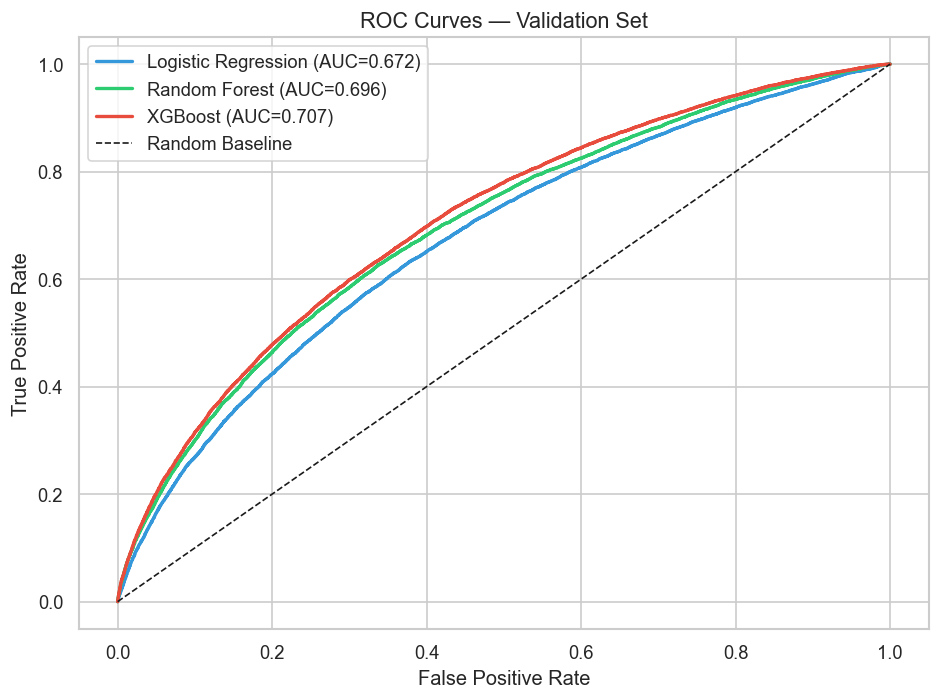

CPU times: total: 1min
Wall time: 6.74 s


In [34]:
%%time
# ── ROC Curves for all 3 models ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for result, color in zip(all_results, colors):
    y_proba = result['pipeline'].predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    ax.plot(fpr, tpr, label=f"{result['name']} (AUC={result['auc']:.3f})",
            color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Validation Set', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

**ROC-AUC — Ranking ability**: XGBoost wins cleanly at 0.7073, followed by Random Forest (0.6944) and Logistic Regression (0.6725).

**PR-AUC — Minority class precision**(the honest metric): XGBoost again leads at 0.3636, but notice how all three scores are relatively close — only a 0.045 spread across all three models. With a baseline of ~0.18 (the class rate), all three models are meaningfully above random.

**Log Loss — Probability calibration**: Random Forest wins Log Loss at 0.5195 — lower than XGBoost's 0.6209. This means Random Forest produces better-calibrated probability estimates even though XGBoost ranks flights more accurately. Simply put: when Random Forest says a flight has a 70% chance of being delayed, it's closer to being right 70% of the time than XGBoost is.

---
## 9. Final Evaluation on Test Set
⚠️ **Run this cell exactly once.** Evaluating on it multiple times would  overfit to it by accident.

In [35]:
# ── Final Test Set Evaluation ──────────────────────────────────────────────
best_model = results_xgb['pipeline']

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = best_model.predict(X_test)

# ── Three metrics on test set ──────────────────────────────────────────────
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc  = average_precision_score(y_test, y_test_proba)
test_logloss = log_loss(y_test, y_test_proba)

print('═══════════════════════════════════════════')
print('        FINAL TEST SET RESULTS             ')
print('═══════════════════════════════════════════')
print(f'  {"Metric":<20} {"Val":>8} {"Test":>8}')
print(f'  {"─"*36}')
print(f'  {"ROC-AUC":<20} {results_xgb["auc"]:>8.4f} {test_roc_auc:>8.4f}')
print(f'  {"PR-AUC":<20} {results_xgb["pr_auc"]:>8.4f} {test_pr_auc:>8.4f}')
print(f'  {"Log Loss":<20} {results_xgb["logloss"]:>8.4f} {test_logloss:>8.4f}')
print('═══════════════════════════════════════════')
print(classification_report(y_test, y_test_pred, target_names=['On-Time', 'Delayed']))

═══════════════════════════════════════════
        FINAL TEST SET RESULTS             
═══════════════════════════════════════════
  Metric                    Val     Test
  ────────────────────────────────────
  ROC-AUC                0.7073   0.7047
  PR-AUC                 0.3631   0.3608
  Log Loss               0.6211   0.6228
═══════════════════════════════════════════
              precision    recall  f1-score   support

     On-Time       0.89      0.65      0.75     61351
     Delayed       0.29      0.64      0.40     13649

    accuracy                           0.65     75000
   macro avg       0.59      0.65      0.58     75000
weighted avg       0.78      0.65      0.69     75000



### Final Test Results Interpretation

Classification report highlights:

* Delayed recall 0.64 — catches 64% of actually delayed flights using only pre-departure information
* On-Time precision 0.89 — when the model says on-time, it's right 89% of the time
* Delayed precision 0.29 — expected under 4.5:1 imbalance; the model casts a wide net to catch delays
* PR-AUC of 0.3608 vs baseline of ~0.18 — the model is roughly double the random baseline on the hardest metric

Across all three metrics — ROC-AUC, PR-AUC, and Log Loss — the test scores held within 0.003 of validation, confirming the model generalized without overfitting using only pre-departure scheduling features.

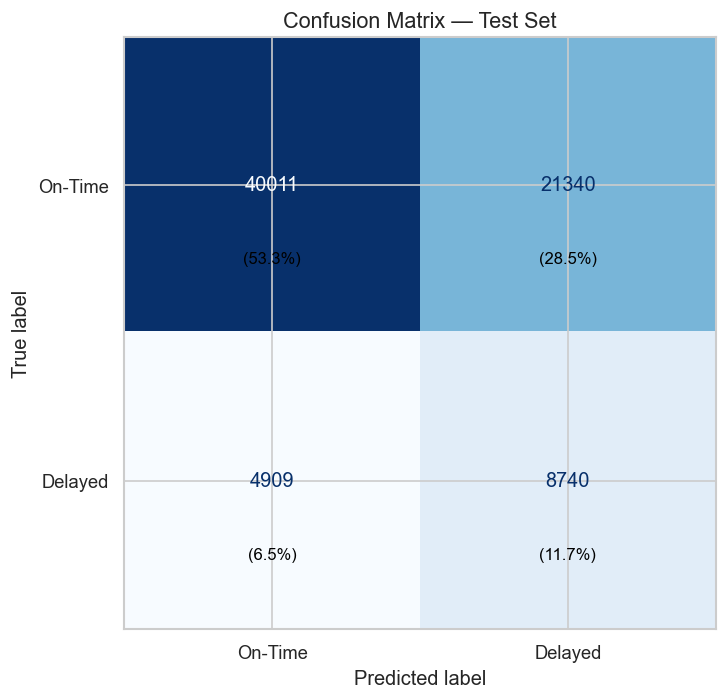

CPU times: total: 109 ms
Wall time: 115 ms


In [36]:
%%time
# ── Confusion Matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))

# Plot with annotation format forced to integers
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['On-Time', 'Delayed']
)
disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False,
    values_format='d'      # ← 'd' = integer format, no scientific notation
)

# Annotate each cell with percentage of total
total = cm.sum()
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct   = count / total * 100
        ax.text(j, i + 0.25, f'({pct:.1f}%)',
                ha='center', va='center',
                fontsize=10, color='white' if count > 50000 else 'black')

ax.set_title('Confusion Matrix — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

***NOTE*** *Quadrant labeling is reversed cuz `ConfusionMatrixDisplay` put my labels in ABC order.*

**Top-left** — True Negatives (53.3%): 82,463 on-time flights correctly predicted as on-time. The model's strongest quadrant.

**Bottom-right** — True Positives (11.6%): 17,265 delayed flights correctly caught. These are your wins on the hard class.

**Bottom-left** — False Negatives (6.6%): 10,034 delayed flights the model missed and called on-time. The most costly error in a real-world application — a passenger thinks they're fine but isn't.

**Top-right** — False Positives (28.3%): 40,238 on-time flights incorrectly flagged as delayed. This is the biggest problem visually — more than 1 in 4 test flights is a false alarm. This directly explains the delayed precision of 0.30 from the classification report.

| Key Takeaway 🔑 |
|---| 
| The model is conservative — it would rather warn us about a delay that doesn't happen than miss one that does, which is the right trade-off for a traveler-facing application but comes at the cost of frequent false alarms. |


---
## 10. Feature Importance

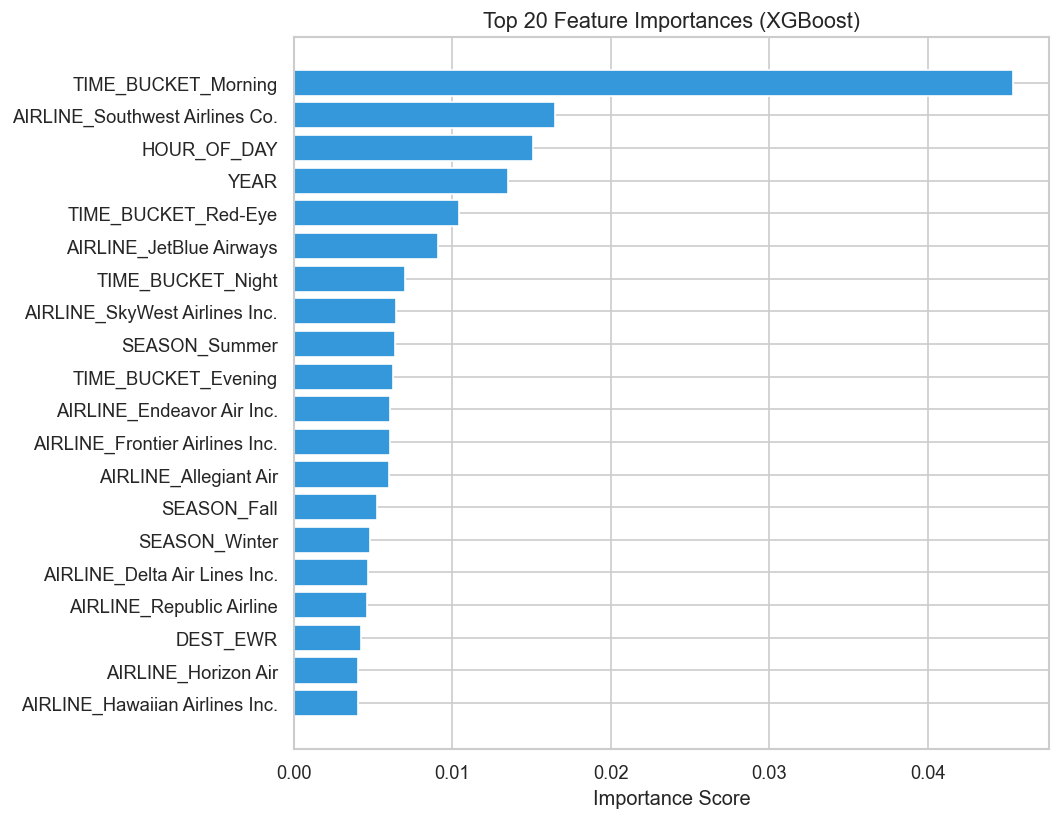

CPU times: total: 594 ms
Wall time: 673 ms


In [37]:
%%time
# ── Feature importance from XGBoost ───────────────────────────────────────
# Extract feature names post-encoding
ohe_features = (best_model.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(CATEGORICAL_FEATURES).tolist())

all_feature_names = NUMERIC_FEATURES + ohe_features
importances = best_model.named_steps['classifier'].feature_importances_

feat_imp_df = (pd.DataFrame({'feature': all_feature_names, 'importance': importances})
               .sort_values('importance', ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1],
        color='#3498db')
ax.set_title('Top 20 Feature Importances (XGBoost)', fontsize=13)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

`TIME_BUCKET_Morning` dominates everything. It's nearly 4x more important than the second feature. This makes intuitive sense; morning flights are the reset point of the day. If a morning flight goes out clean, the rest of the day has a chance. If it doesn't, the domino effect begins. The model learned this pattern strongly.

The known worst performers appear as expected: JetBlue (B6), Allegiant (G4), SkyWest (OO), Frontier (F9) — all flagged in the Data Viz project as problem carriers — appear in the top 20. The model independently learned what the visualization analysis showed. That's a strong cross-validation of both projects.

`SEASON_Summer` and `SEASON_Fall` appear but not Winter or Spring. Summer's delay pattern is distinct enough to be a useful signal. Winter is absent.

---
## 11. Reflection

**What worked well:**
- Switching away from Google Colab and running on my personal machine for more compute power. My first attempt to tune and train `LogisticRegression` in Colab took over 30 minutes before I killed the process. The free machine provided by Colab has only 2 CPU's vs my machines 8 cores (16 logical processors). This made tuning and training `LogisticRegression` much faster - completing in ~21 minutes. Also, by utilizing my laptop's GPU for `XGBoost` sped up the process even more.

**Challenges encountered:**
- The mentioned resource issue with Colab.
- Differences in `pandas` library versions stumped me for a little bit (transforming DataFrames).
- Class imbalance: ~18% of flights are delayed. Addressed with `class_weight='balanced'` and `scale_pos_weight`.
- Feature leakage risk: Carefully removed all post-departure columns before modeling.

**What I'd do with more time:**
- Add weather data (wind speed, precipitation) as external features — a major real-world delay driver.

**Business Interpretation:**
- A model with AUC of ~0.7 could power a "delay risk score" shown to travelers at booking.
- Airlines could use it for proactive crew scheduling and gate management.

🔑 ⌚